In [4]:
# import tree_comparison.tree_compare as tc
# from joblib import Memory
from itertools import combinations
import pandas as pd
import numpy as np
# from utils import *
import utils as u

In [5]:
morphos, soma_df = u.load_all()

In [ ]:
# import trimesh
# # 
# # Load mesh
# mesh = trimesh.load('/root/capsule/data/lc_meshes/20250418_transformed_remesh_10.obj')

# 3d plots

In [1]:
import navis

In [ ]:
# uses trimesh
mesh = navis.read_mesh('/root/capsule/data/lc_meshes/20250418_transformed_remesh_10.obj')


In [7]:
morphos

{'/data/685222_2_17_25_unrefined/Complete_annotated/N040-685222-VM.json': <neuron_morphology.morphology.Morphology at 0x7f49bae1f5e0>,
 '/data/685222_2_17_25_unrefined/Complete_annotated/N024-685222-AP.json': <neuron_morphology.morphology.Morphology at 0x7f4997587e50>,
 '/data/685222_2_17_25_unrefined/Complete_annotated/N029-685222-SA.json': <neuron_morphology.morphology.Morphology at 0x7f4997587a60>,
 '/data/685222_2_17_25_unrefined/Complete_annotated/N017-685222-DS.json': <neuron_morphology.morphology.Morphology at 0x7f49bae1f4c0>,
 '/data/685222_2_17_25_unrefined/Complete_annotated/N033-685222-YP.json': <neuron_morphology.morphology.Morphology at 0x7f49bae1f730>,
 '/data/685222_2_17_25_unrefined/Complete_annotated/N025-685222-SA.json': <neuron_morphology.morphology.Morphology at 0x7f4997587ee0>,
 '/data/685222_2_17_25_unrefined/Complete_annotated/N013-685222-DS.json': <neuron_morphology.morphology.Morphology at 0x7f49bae1ff40>,
 '/data/685222_2_17_25_unrefined/Complete_annotated/N03

In [ ]:
neuron = navis.TreeNeuron()
navis.plot3d(mesh)

INFO  : Using "plotly" backend for 3D plotting. (navis)


In [ ]:
import k3d

plot = k3d.plot()
plot += k3d.mesh(mesh.vertices, mesh.faces, opacity=0.5, color=0xFF0000)
plot += k3d.points(soma_df[["x", "y", "z"]].values, point_size=20, shader="3d", color=0x00FF00)
plot.display()

# LC mesh comparisons

 Dendrites relationship to edges
 - direction correlation with surface normalize?
 - magnitude of dendrite CoM anticorrelated with distance to surface?

In [ ]:
# install trimesh, rtree

In [ ]:

soma_df["z"] = np.minimum(soma_df["z"], 11400-soma_df["z"])
soma_df[["x", "y", "z"]].mean()
soma_center = soma_df[["x", "y", "z"]].mean().values
mesh_center = mesh.bounding_box.centroid
soma_center - mesh_center

array([105.99100354,  68.8277215 , -51.85861085])

In [ ]:
# offset gives 80 vs 73 (out of 104) cells inside

# mesh.vertices = mesh.vertices + soma_center - mesh_center

In [ ]:

# Query point
point = mesh_center

# Find closest point on mesh
closest_point, distance, triangle_id = trimesh.proximity.closest_point(mesh, [point])

print(f"Closest point: {closest_point[0]}")
print(f"Distance: {distance[0]}")

Closest point: [10452.62358245  4484.96890442  4895.85679036]
Distance: 129.19887102181175


In [ ]:
records = []
for _, row in soma_df.iterrows():
    point = row[["x", "y", "z"]].values 
    # check if point is inside the mesh
    inside = mesh.contains([point])
    if not inside[0]:
        continue
    closest_point, distance, triangle_id = trimesh.proximity.closest_point(mesh, [point])
    ds = point - closest_point[0]
    scaled_sep = ds / np.linalg.norm(ds)
    morpho = morphos[row["file"]]

    # is sampling uniform??
    dend_sep = (
        pd.DataFrame.from_records(morpho.get_node_by_types([BASAL_DENDRITE]))[["x", "y", "z"]].mean() -
        pd.DataFrame.from_records(morpho.get_node_by_types([SOMA]))[["x", "y", "z"]].mean()
    )
    dend_dist = np.linalg.norm(dend_sep)
    dend_sep = dend_sep / dend_dist
    records.append({
        "file": row["file"],
        "distance": distance[0],
        "dend_distance": dend_dist,
        "scaled_sep": scaled_sep,
        "dend_sep": dend_sep,
        "scaled_sep_x": scaled_sep[0],
        "scaled_sep_y": scaled_sep[1],
        "scaled_sep_z": scaled_sep[2],
        "dend_sep_x": dend_sep[0],
        "dend_sep_y": dend_sep[1],
        "dend_sep_z": dend_sep[2],
    })
df = pd.DataFrame.from_records(records)



NameError: name 'BASAL_DENDRITE' is not defined

In [ ]:
f"{len(df)} cells within boundaries, {len(soma_df)} cells total"

'73 cells within boundaries, 104 cells total'

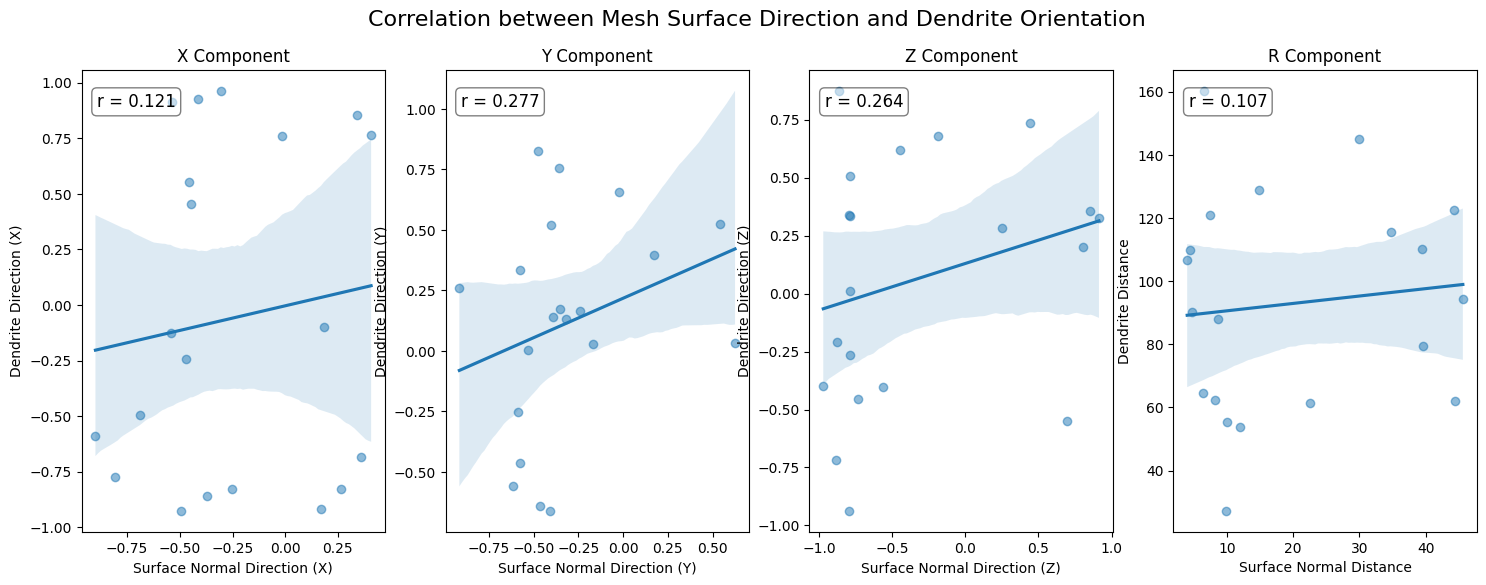

In [ ]:
# Create a figure with 4 subplots for the x, y, and z components along with distance

fig, axes = plt.subplots(1, 4, figsize=(18, 6))
records = df
records = records[records['distance'] < 50]
# Add title to the overall figure
fig.suptitle("Correlation between Mesh Surface Direction and Dendrite Orientation", fontsize=16)

# Plot x component
sns.regplot(x="scaled_sep_x", y="dend_sep_x", data=records, ax=axes[0], scatter_kws={'alpha': 0.5})
axes[0].set_title("X Component")
axes[0].set_xlabel("Surface Normal Direction (X)")
axes[0].set_ylabel("Dendrite Direction (X)")
r_x = np.corrcoef(records['scaled_sep_x'], records['dend_sep_x'])[0, 1]
axes[0].text(0.05, 0.95, f"r = {r_x:.3f}", transform=axes[0].transAxes, fontsize=12, 
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

# Plot y component
sns.regplot(x="scaled_sep_y", y="dend_sep_y", data=records, ax=axes[1], scatter_kws={'alpha': 0.5})
axes[1].set_title("Y Component")
axes[1].set_xlabel("Surface Normal Direction (Y)")
axes[1].set_ylabel("Dendrite Direction (Y)")
r_y = np.corrcoef(records['scaled_sep_y'], records['dend_sep_y'])[0, 1]
axes[1].text(0.05, 0.95, f"r = {r_y:.3f}", transform=axes[1].transAxes, fontsize=12, 
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

# Plot z component
sns.regplot(x="scaled_sep_z", y="dend_sep_z", data=records, ax=axes[2], scatter_kws={'alpha': 0.5})
axes[2].set_title("Z Component")
axes[2].set_xlabel("Surface Normal Direction (Z)")
axes[2].set_ylabel("Dendrite Direction (Z)")
r_z = np.corrcoef(records['scaled_sep_z'], records['dend_sep_z'])[0, 1]
axes[2].text(0.05, 0.95, f"r = {r_z:.3f}", transform=axes[2].transAxes, fontsize=12, 
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

fig = create_morphology_scatter_plot(embedding, morphos, files, coords='xy')
# Plot z component
sns.regplot(x="distance", y="dend_distance", data=records, ax=axes[3], scatter_kws={'alpha': 0.5})
axes[3].set_title("R Component")
axes[3].set_xlabel("Surface Normal Distance")
axes[3].set_ylabel("Dendrite Distance")
r_z = np.corrcoef(records['distance'], records['dend_distance'])[0, 1]
axes[3].text(0.05, 0.95, f"r = {r_z:.3f}", transform=axes[3].transAxes, fontsize=12, 
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))
# plt.tight_layout()
plt.subplots_adjust(top=0.88)